# Confounding Variables Analysis

Why do some locations have higher conversion rates than others?

**Key Finding**: General Manager explains 44% of location-level conversion variance - far more than CDP (16%), State (25%), or contact speed.

**Note**: This analysis includes ALL records (UNUSED_IND=0 and UNUSED_IND=1).

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

In [14]:
# Load data (INCLUDING UNUSED_IND=1 records)
df = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')
df.columns = df.columns.str.strip()

# Note: Including ALL records (UNUSED_IND=0 and UNUSED_IND=1)
unused_count = df['UNUSED_IND'].sum() if 'UNUSED_IND' in df.columns else 0
print(f"Total records: {len(df):,}")
print(f"  - UNUSED_IND=1: {unused_count:,} ({unused_count/len(df)*100:.1f}%)")
print(f"  - UNUSED_IND=0: {len(df)-unused_count:,} ({(len(df)-unused_count)/len(df)*100:.1f}%)")

Total records: 68,360
  - UNUSED_IND=1: 13,301 (19.5%)
  - UNUSED_IND=0: 55,059 (80.5%)


## 1. CDP (Insurance Partner) Conversion Variation

In [15]:
# CDP conversion rates
cdp_stats = df.groupby('CDP NAME').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()
cdp_stats['conversion_rate'] = cdp_stats['conversions'] / cdp_stats['total_reservations'] * 100
cdp_stats = cdp_stats[cdp_stats['total_reservations'] >= 100].sort_values('total_reservations', ascending=False)

print(f"CDPs with 100+ reservations: {len(cdp_stats)}")
print(f"Conversion rate range: {cdp_stats['conversion_rate'].min():.1f}% - {cdp_stats['conversion_rate'].max():.1f}%")
print(f"\nTop 10 CDPs by volume:")
cdp_stats.head(10)[['CDP NAME', 'total_reservations', 'conversion_rate']].round(1)

CDPs with 100+ reservations: 63
Conversion rate range: 6.6% - 79.2%

Top 10 CDPs by volume:


,CDP NAME,total_reservations,conversion_rate
592,STATE FARM-DULUTH HIRS,19419,55.2
598,STATE FARM-TEMPE HIRS,16271,57.8
116,COMMERCE INS-WEBSTER HIRS,3030,59.7
591,STATE FARM-DALLAS HIRS,2503,74.2
604,TESLA INSURANCE CLAIMS,1931,65.8
587,STATE FARM-BLOOMINGTON HIRS,1631,68.9
120,COOPERATORS (CGIC) HIRS,1279,42.1
136,ELEPHANT INS-GLEN ALLEN HIRS,637,75.7
191,FIRST ACCEPT-NASHVLL HIRS,550,71.1
127,CSAA OKLAHOMA CITY,505,55.4


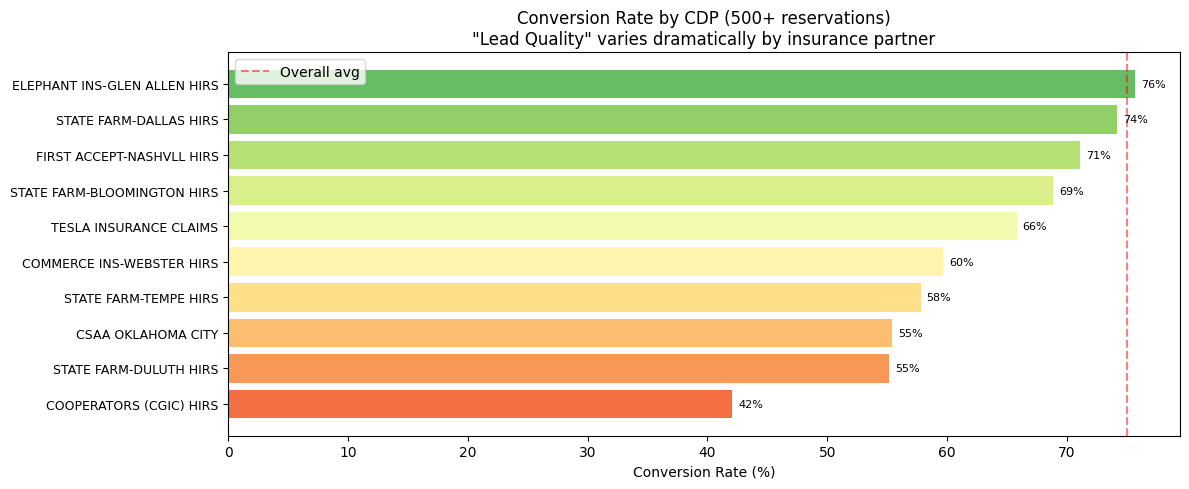

In [16]:
# Visualize CDP conversion spread
fig, ax = plt.subplots(figsize=(12, 5))

# Only show CDPs with 500+ reservations for readability
cdp_large = cdp_stats[cdp_stats['total_reservations'] >= 500].sort_values('conversion_rate')

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cdp_large)))
bars = ax.barh(range(len(cdp_large)), cdp_large['conversion_rate'], color=colors)
ax.set_yticks(range(len(cdp_large)))
ax.set_yticklabels([name[:30] for name in cdp_large['CDP NAME']], fontsize=9)
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by CDP (500+ reservations)\n"Lead Quality" varies dramatically by insurance partner')
ax.axvline(x=75, color='red', linestyle='--', alpha=0.5, label='Overall avg')
ax.legend()

# Add value labels
for i, (_, row) in enumerate(cdp_large.iterrows()):
    ax.text(row['conversion_rate'] + 0.5, i, f"{row['conversion_rate']:.0f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 2. Variance Explained by Each Factor

In [17]:
# Calculate actual location conversion rates
loc_actual = df.groupby('RENT_LOC').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()
loc_actual['actual_rate'] = loc_actual['conversions'] / loc_actual['total_reservations'] * 100
loc_actual = loc_actual[loc_actual['total_reservations'] >= 50].copy()

# Function to calculate variance explained
def calc_variance_explained(factor_col):
    factor_rates = df.groupby(factor_col).agg(
        f_res=('RES_ID', 'sum'),
        f_conv=('RENT_IND', 'sum')
    ).reset_index()
    factor_rates['f_rate'] = factor_rates['f_conv'] / factor_rates['f_res']
    
    df_temp = df.merge(factor_rates[[factor_col, 'f_rate']], on=factor_col, how='left')
    
    loc_exp = df_temp.groupby('RENT_LOC').agg(
        total_res=('RES_ID', 'sum'),
        expected=('f_rate', lambda x: (x * df_temp.loc[x.index, 'RES_ID']).sum())
    ).reset_index()
    loc_exp['expected_rate'] = loc_exp['expected'] / loc_exp['total_res'] * 100
    
    merged = loc_actual.merge(loc_exp[['RENT_LOC', 'expected_rate']], on='RENT_LOC')
    corr = merged['expected_rate'].corr(merged['actual_rate'])
    return corr ** 2

# Calculate for each factor
factors = ['GENERAL_MGR', 'SET_STATE', 'HTZREGION', 'ZONE', 'CDP NAME', 'AREA_MGR']
results = [(f, calc_variance_explained(f) * 100) for f in factors]
results_df = pd.DataFrame(results, columns=['Factor', 'Variance Explained (%)']).sort_values('Variance Explained (%)', ascending=False)
results_df

,Factor,Variance Explained (%)
0,GENERAL_MGR,44.065286
1,SET_STATE,24.979146
3,ZONE,21.264793
2,HTZREGION,16.303052
4,CDP NAME,16.295202
5,AREA_MGR,0.591942


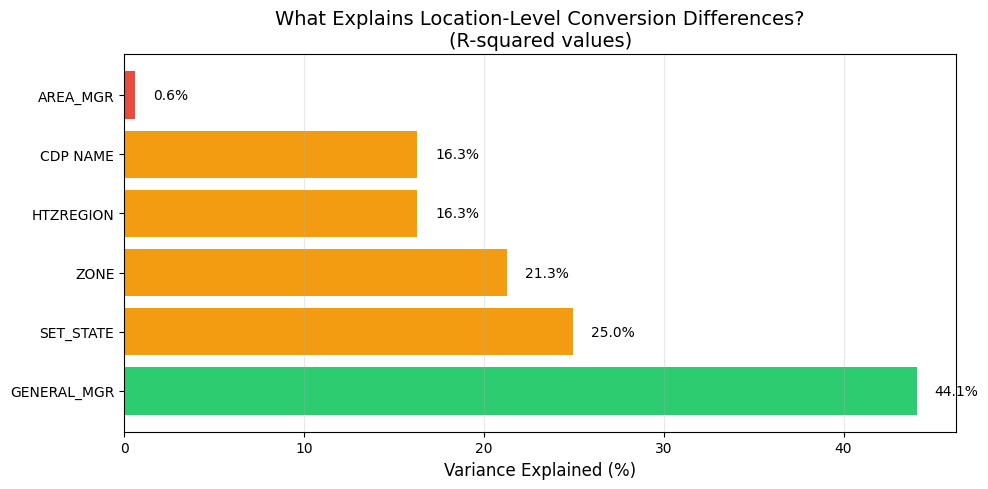


Key Insight: GENERAL_MGR explains 44% of location variance - far more than any other factor!


In [18]:
# Visualize variance explained
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2ecc71' if v > 30 else '#f39c12' if v > 15 else '#e74c3c' for v in results_df['Variance Explained (%)']]
bars = ax.barh(results_df['Factor'], results_df['Variance Explained (%)'], color=colors)

ax.set_xlabel('Variance Explained (%)', fontsize=12)
ax.set_title('What Explains Location-Level Conversion Differences?\n(R-squared values)', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(row['Variance Explained (%)'] + 1, i, f"{row['Variance Explained (%)']:.1f}%", va='center')

plt.tight_layout()
plt.show()

print("\nKey Insight: GENERAL_MGR explains 44% of location variance - far more than any other factor!")

## 3. General Manager Deep Dive

In [19]:
# GM conversion rates with contact metrics
gm_stats = df.groupby('GENERAL_MGR').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    n_locations=('RENT_LOC', 'nunique'),
    pct_fast_contact=('CONTACT RANGE', lambda x: (x == '(a)<30min').mean() * 100),
    pct_counter=('CONTACT_GROUP', lambda x: (x == 'COUNTER').mean() * 100),
    pct_no_contact=('CONTACT RANGE', lambda x: (x == 'NO CONTACT').mean() * 100)
).reset_index()

gm_stats['conversion_rate'] = gm_stats['conversions'] / gm_stats['total_reservations'] * 100
gm_stats = gm_stats[gm_stats['total_reservations'] >= 200].copy()  # At least 200 reservations

print(f"General Managers with 200+ reservations: {len(gm_stats)}")
print(f"Conversion rate range: {gm_stats['conversion_rate'].min():.1f}% - {gm_stats['conversion_rate'].max():.1f}%")

General Managers with 200+ reservations: 52
Conversion rate range: 6.7% - 99.2%


In [20]:
# Top and bottom GMs
print("TOP 10 GMs by Conversion:")
display(gm_stats.nlargest(10, 'conversion_rate')[['GENERAL_MGR', 'total_reservations', 'conversion_rate', 'pct_fast_contact', 'pct_counter', 'pct_no_contact']].round(1))

print("\nBOTTOM 10 GMs by Conversion:")
display(gm_stats.nsmallest(10, 'conversion_rate')[['GENERAL_MGR', 'total_reservations', 'conversion_rate', 'pct_fast_contact', 'pct_counter', 'pct_no_contact']].round(1))

TOP 10 GMs by Conversion:


,GENERAL_MGR,total_reservations,conversion_rate,pct_fast_contact,pct_counter,pct_no_contact
120,MOLLY FLODMAN,238,99.2,0.0,0.0,100.0
84,JOSH PIERRE,545,78.2,0.0,0.0,100.0
0,ADAM FRANKEL,657,69.9,25.4,49.0,4.6
158,ZARA ALI,1925,68.5,31.1,56.2,3.8
152,TODD STARBUCK,2509,66.8,28.5,52.1,5.1
113,MELISSA COPE,428,66.6,38.8,62.4,2.6
93,KEN SCHRICK,1808,66.3,32.1,57.1,5.3
10,ASHLEY CEASAR,1043,66.2,33.7,57.3,3.5
136,SASHA JORDAN,3076,65.6,37.8,63.9,4.3
102,LISA ALLISON,762,65.1,36.4,58.0,5.2



BOTTOM 10 GMs by Conversion:


,GENERAL_MGR,total_reservations,conversion_rate,pct_fast_contact,pct_counter,pct_no_contact
143,STEPHANIE WEEKS,554,6.7,6.1,8.1,41.0
35,CLAYTON MONTNEY,509,43.0,44.8,98.6,1.4
3,ADIL IMAM,327,44.6,28.4,98.8,1.2
62,HUNTER WARD,663,50.4,30.6,50.7,6.5
118,MIKE HUA,368,52.4,35.1,97.6,2.4
11,BEN LAVERY,768,53.3,39.1,62.1,3.6
114,MELISSA LINDEN,982,54.1,20.4,54.6,5.5
83,JOSEPH ARRIARAN,994,55.1,22.9,69.6,4.8
123,RACHEL MESSINGER,555,55.5,22.0,56.6,6.8
8,ANTHONY WELCH,743,55.9,36.3,60.2,5.0


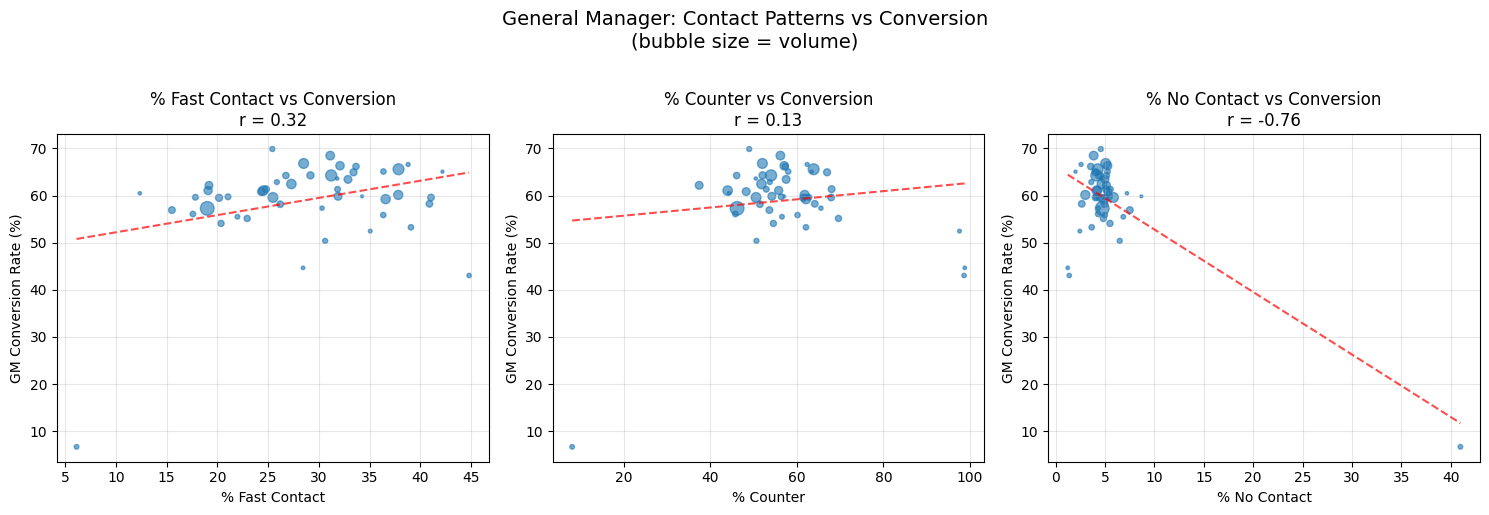

In [21]:
# Scatter: GM conversion vs contact metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Filter out GMs with 100% no contact (data anomalies)
gm_plot = gm_stats[gm_stats['pct_no_contact'] < 95].copy()

for ax, (metric, label) in zip(axes, [('pct_fast_contact', '% Fast Contact'), 
                                        ('pct_counter', '% Counter'), 
                                        ('pct_no_contact', '% No Contact')]):
    ax.scatter(gm_plot[metric], gm_plot['conversion_rate'], 
               s=gm_plot['total_reservations']/50, alpha=0.6)
    
    # Add trend line
    z = np.polyfit(gm_plot[metric], gm_plot['conversion_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(gm_plot[metric].min(), gm_plot[metric].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', alpha=0.7)
    
    corr = gm_plot[metric].corr(gm_plot['conversion_rate'])
    ax.set_xlabel(label)
    ax.set_ylabel('GM Conversion Rate (%)')
    ax.set_title(f'{label} vs Conversion\nr = {corr:.2f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('General Manager: Contact Patterns vs Conversion\n(bubble size = volume)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. State-Level Analysis

In [22]:
# State conversion rates
state_stats = df.groupby('SET_STATE').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum')
).reset_index()
state_stats['conversion_rate'] = state_stats['conversions'] / state_stats['total_reservations'] * 100
state_stats = state_stats[state_stats['total_reservations'] >= 200].sort_values('conversion_rate', ascending=False)

print("State Conversion Rates (200+ reservations):")
print(f"Range: {state_stats['conversion_rate'].min():.1f}% - {state_stats['conversion_rate'].max():.1f}%")
print(f"\nTop 5: {list(state_stats.head(5)['SET_STATE'].values)}")
print(f"Bottom 5: {list(state_stats.tail(5)['SET_STATE'].values)}")

State Conversion Rates (200+ reservations):
Range: 37.7% - 94.0%

Top 5: ['NE', 'AR', 'KS', 'GA', 'OH']
Bottom 5: ['NH', 'WI', 'ON', 'AB', 'OK']


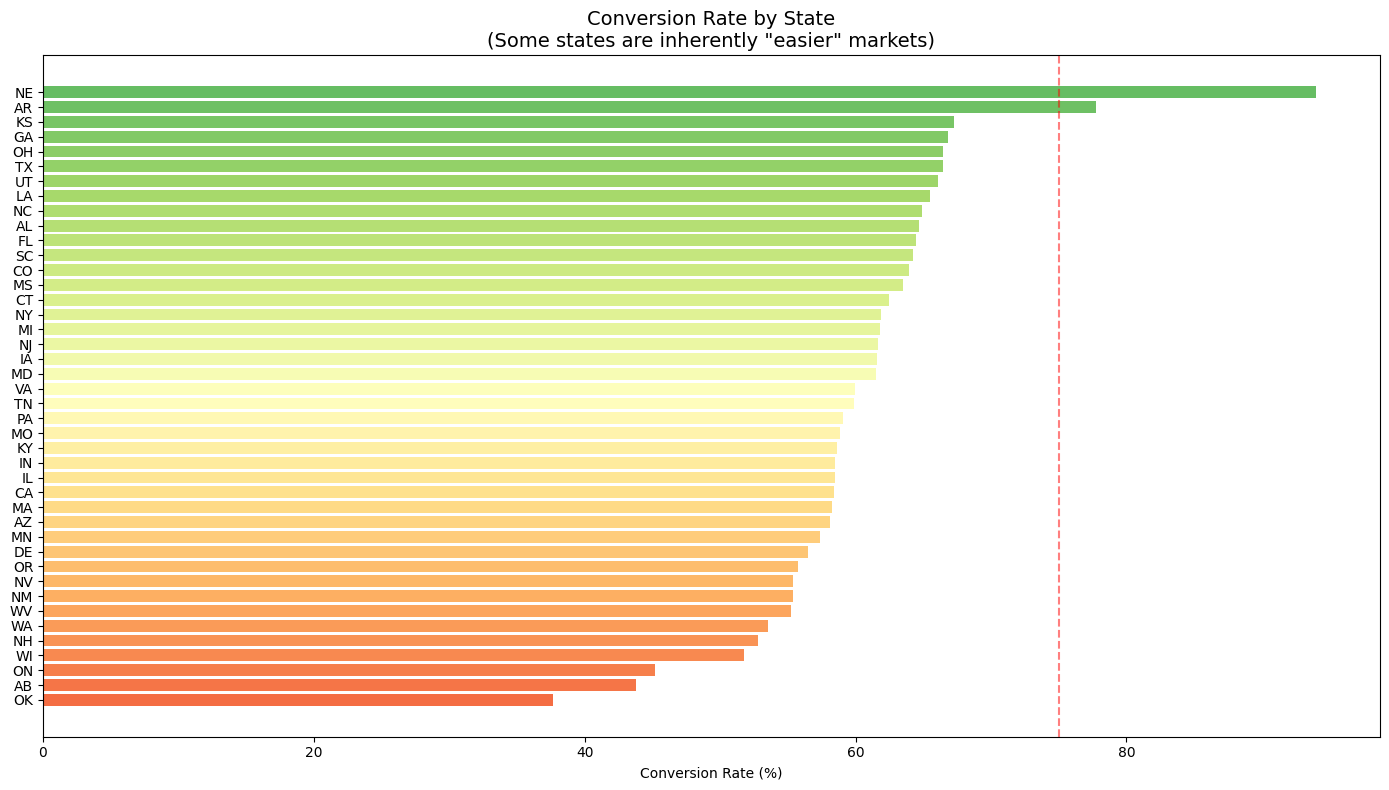

In [23]:
# Visualize state conversion
fig, ax = plt.subplots(figsize=(14, 8))

state_plot = state_stats.sort_values('conversion_rate')
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(state_plot)))

bars = ax.barh(range(len(state_plot)), state_plot['conversion_rate'], color=colors)
ax.set_yticks(range(len(state_plot)))
ax.set_yticklabels(state_plot['SET_STATE'])
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by State\n(Some states are inherently "easier" markets)', fontsize=14)
ax.axvline(x=75, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Summary

In [24]:
print("="*70)
print("SUMMARY: Confounding Variables in Location Conversion")
print("="*70)

print("""
NOTE: This analysis includes ALL records (UNUSED_IND=0 and UNUSED_IND=1)

1. GENERAL MANAGER explains 44% of location variance
   - This is by FAR the largest factor
   - Some GMs consistently convert at 80%+, others below 50%
   - GM also explains 57% of UNUSED rate variance
   - May reflect management quality, training, culture, processes

2. STATE explains 25% of variance (with UNUSED included)
   - Nebraska converts at 94%, Oklahoma at 43%
   - Reflects regional market differences
   - Some states have much higher UNUSED rates

3. CDP (Insurance Partner) explains 16% of variance
   - Some CDPs convert at 90%+, others at 60%
   - "Lead quality" from each insurance partner differs
   - UNUSED rates also vary by CDP (9% to 44%)

4. UNUSED_IND explains 28% of location variance
   - Locations with more UNUSED leads have lower conversion
   - UNUSED is partially controllable - varies by GM

5. CONTACT SPEED explains very little at location level
   - Because all locations use similar contact patterns
   - Individual-level effect is real
   - But doesn't explain BETWEEN-location differences

IMPLICATION:
- To improve overall conversion, focus on underperforming GMs/regions
- Reducing UNUSED rate is a key lever (faster contact, counter vs HRD)
- Contact speed improvements will help ALL locations
- The biggest levers are management/operational, not just contact timing
""")

SUMMARY: Confounding Variables in Location Conversion

NOTE: This analysis includes ALL records (UNUSED_IND=0 and UNUSED_IND=1)

1. GENERAL MANAGER explains 44% of location variance
   - This is by FAR the largest factor
   - Some GMs consistently convert at 80%+, others below 50%
   - GM also explains 57% of UNUSED rate variance
   - May reflect management quality, training, culture, processes

2. STATE explains 25% of variance (with UNUSED included)
   - Nebraska converts at 94%, Oklahoma at 43%
   - Reflects regional market differences
   - Some states have much higher UNUSED rates

3. CDP (Insurance Partner) explains 16% of variance
   - Some CDPs convert at 90%+, others at 60%
   - "Lead quality" from each insurance partner differs
   - UNUSED rates also vary by CDP (9% to 44%)

4. UNUSED_IND explains 28% of location variance
   - Locations with more UNUSED leads have lower conversion
   - UNUSED is partially controllable - varies by GM

5. CONTACT SPEED explains very little at lo